<a href="https://colab.research.google.com/github/francji1/01RAD/blob/main/HW/01RAD_Ex01_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01RAD - Homework 01: Cars braking distance

Investigate the relationship between the speed of a car and its stopping distance using the classic `cars` dataset (50 observations recorded in the 1920s: `speed` in mph, `dist` in ft).

Use the notation of Lecture 1: model $Y_i = \beta_0 + \beta_1 x_i + e_i$, least squares estimates $\widehat{\beta}_0, \widehat{\beta}_1$, residuals $\widehat{e}_i$, unbiased variance estimate $s_n^2 = SSE/(n-2)$.

## Submission
Work through the tasks below in this notebook (code plus short written answers in markdown cells). Python is the default, but you may equally solve the tasks in R (`lm(dist ~ speed, data = cars)`), the questions are the same.

Submit your solution through GitHub **before the next exercise**:
1. fork the course repository `francji1/01RAD`,
2. save your notebook into the `HW/` folder as `01RAD_Ex01_HW_<Surname>.ipynb` (for example `01RAD_Ex01_HW_Novak.ipynb`; for a team join the surnames with an underscore),
3. open a pull request to the `main` branch of `francji1/01RAD`.

A selected student solution and a reference solution will be published in the `HW/` folder a week later.

## Data

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style='whitegrid', palette='deep')

url_cars = 'https://raw.githubusercontent.com/francji1/01RAD/main/data/cars.csv'
url_local = "../data/cars.csv"
try:
    cars = pd.read_csv(url_local)
except Exception:
    # fallback: the same data set from R's datasets package via statsmodels
    cars = sm.datasets.get_rdataset('cars', package='datasets').data
print(f'Rows: {cars.shape[0]}, columns: {cars.shape[1]}')
cars.head()

Rows: 50, columns: 2


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


## Task 01 - Inspect the data
Inspect the structure of the dataset (`info()`, `describe()`). Which variable is the response and which the explanatory variable here, and why?

In [13]:
# your solution
cars.info()
print()
cars.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   speed   50 non-null     int64
 1   dist    50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes



,count,mean,std,min,25%,50%,75%,max
speed,50.0,15.40,5.287644,4.0,12.0,15.0,19.0,25.0
dist,50.0,42.98,25.769377,2.0,26.0,36.0,56.0,120.0


response = distance

explanatory = speed

since speed influences the distance

## Task 02 - Plots
Plot histograms with density curves for `speed` and `dist`, and the scatter plot of `dist` against `speed`. Comment on the shape of the relationship.

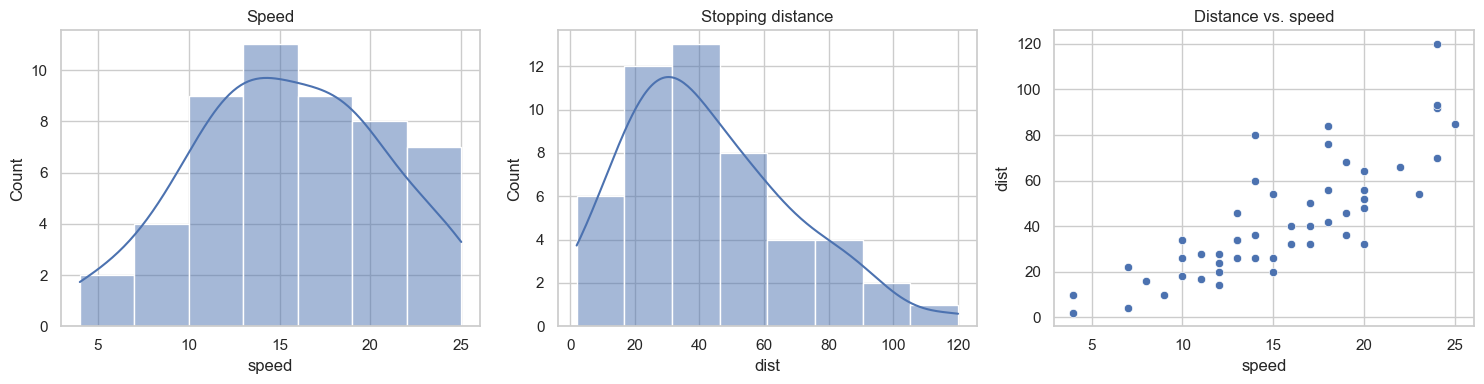

In [14]:
# your solution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(cars['speed'], kde=True, ax=axes[0])
axes[0].set_title('Speed')

sns.histplot(cars['dist'], kde=True, ax=axes[1])
axes[1].set_title('Stopping distance')

sns.scatterplot(x='speed', y='dist', data=cars, ax=axes[2])
axes[2].set_title('Distance vs. speed')

plt.tight_layout()
plt.show()

z scatterplotu je videt urcita "linearni" zavislost - ale i lehke zakriveni nahoru, ale ve vetsich rychlostech se opticky zvetsuje variance. 

Na první pohled jsou rychlostni data rozdelena normalne a stopping distance pripomina spise gammu.

## Task 03 - Least squares by hand
Fit the simple linear regression model manually, both with intercept ($Y_i = \beta_0 + \beta_1 x_i + e_i$) and without intercept ($Y_i = \beta_1 x_i + e_i$, regression through the origin). Derive $\widehat{\beta}_0$ and $\widehat{\beta}_1$ from the sums (Lecture 1, formula (2.1)); for the model without intercept derive the estimate from its single normal equation. *Hint:* minimising $\sum_i (y_i - \beta_1 x_i)^2$ gives $\widehat{\beta}_1 = \sum_i x_i y_i / \sum_i x_i^2$, see Exercise 01, section 8.

In [15]:
# your solution
X = cars['speed'].to_numpy()   
Y = cars['dist'].to_numpy()  
n = len(X)

x_mean = X.mean()
y_mean = Y.mean()

# w/ intercept
beta1_hat = (np.sum(X * Y) - n * x_mean * y_mean) / (np.sum(X ** 2) - n * x_mean ** 2)
beta0_hat = y_mean - beta1_hat * x_mean

print(f"With intercept: \nbeta1_hat = {beta1_hat:.6f}, \nbeta0_hat = {beta0_hat:.6f}")

# bez interceptu
beta1_origin = np.sum(X * Y) / np.sum(X ** 2)

print(f"Without: \nbeta1_hat = {beta1_origin:.6f}")

With intercept: 
beta1_hat = 3.932409, 
beta0_hat = -17.579095
Without: 
beta1_hat = 2.909132


## Task 04 - Residual sum of squares and $s_n^2$
Compute the residual sum of squares $SSE$ and the unbiased estimate of the error variance for each model. Mind the degrees of freedom: $n-2$ with intercept, $n-1$ without.

In [16]:
# your solution
# w/intercept
y_hat = beta0_hat + beta1_hat * X
e_hat = Y - y_hat
SSE = np.sum(e_hat ** 2)
s_n2 = SSE / (n - 2)

print(f"With intercept: \nSSE = {SSE:.4f}, \ns_n^2 = {s_n2:.4f}\n")

# bez interceptu
y_hat_origin = beta1_origin * X
e_hat_origin = Y - y_hat_origin
SSE_origin = np.sum(e_hat_origin ** 2)
s_n2_origin = SSE_origin / (n - 1)

print(f"Without: \nSSE = {SSE_origin:.4f}, \ns_n^2 = {s_n2_origin:.4f}")

With intercept: 
SSE = 11353.5211, 
s_n^2 = 236.5317

Without: 
SSE = 12953.7768, 
s_n^2 = 264.3628


## Task 05 - Standard errors
Derive the estimated variances and standard errors of the estimated parameters in both models. Check them against `statsmodels` (`.bse`). *Hint:* for the model with intercept use the formulas previewed in Exercise 01, section 7; for the model through the origin $\mathrm{Var}(\widehat{\beta}_1) = \sigma^2 / \sum_i x_i^2$, with $\sigma^2$ estimated by $s_n^2$ on $n-1$ degrees of freedom.

In [17]:
# your solution
# w/intercept
S_xx = np.sum((X - x_mean) ** 2)
delta_0 = 1 / n + x_mean ** 2 / S_xx
delta_1 = 1 / S_xx

var_beta0_hat = s_n2 * delta_0
var_beta1_hat = s_n2 * delta_1
se_beta0_hat = np.sqrt(var_beta0_hat)
se_beta1_hat = np.sqrt(var_beta1_hat)

print(f"With intercept: \nSE(beta0_hat) = {se_beta0_hat:.6f}, \nSE(beta1_hat) = {se_beta1_hat:.6f}\n")

# bez interceptu
var_beta1_origin = s_n2_origin / np.sum(X ** 2)
se_beta1_origin = np.sqrt(var_beta1_origin)

print(f"Without: \nSE(beta1_hat) = {se_beta1_origin:.6f}\n")

# --- Check against statsmodels ---
model_with_intercept = smf.ols('dist ~ speed', data=cars).fit()
model_origin = smf.ols('dist ~ speed - 1', data=cars).fit()

pd.DataFrame({
    'quantity': ['beta0_hat', 'beta1_hat', 'SE(beta0_hat)', 'SE(beta1_hat)'],
    'manual (with intercept)': [beta0_hat, beta1_hat, se_beta0_hat, se_beta1_hat],
    'statsmodels (with intercept)': [model_with_intercept.params['Intercept'], model_with_intercept.params['speed'],
                                      model_with_intercept.bse['Intercept'], model_with_intercept.bse['speed']],
    'manual (without intercept)': [np.nan, beta1_origin, np.nan, se_beta1_origin],
    'statsmodels (without intercept)': [np.nan, model_origin.params['speed'],
                                      np.nan, model_origin.bse['speed']]
})

With intercept: 
SE(beta0_hat) = 6.758440, 
SE(beta1_hat) = 0.415513

Without: 
SE(beta1_hat) = 0.141369



,quantity,manual (with intercept),statsmodels (with intercept),manual (without intercept),statsmodels (without intercept)
0,beta0_hat,-17.579095,-17.579095,NaN,NaN
1,beta1_hat,3.932409,3.932409,2.909132,2.909132
2,SE(beta0_hat),6.758440,6.758440,NaN,NaN
3,SE(beta1_hat),0.415513,0.415513,0.141369,0.141369


## Task 06 - Fitted lines
Plot the data together with both fitted regression lines on the same axes.

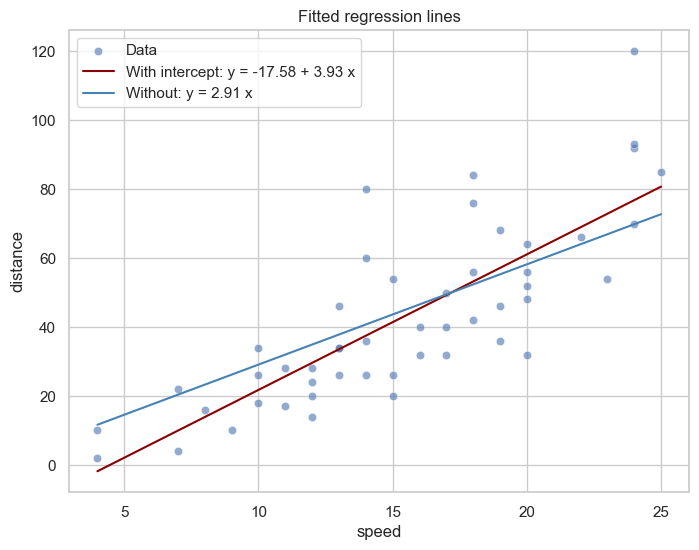

In [18]:
# your solution
x_line = np.linspace(X.min(), X.max(), 100)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X, y=Y, alpha=0.6, label='Data')

# w/intercept
plt.plot(x_line, beta0_hat + beta1_hat * x_line, color='darkred',
          label=f'With intercept: y = {beta0_hat:.2f} + {beta1_hat:.2f} x')

# bez interceptu
plt.plot(x_line, beta1_origin * x_line, color='steelblue',
          label=f'Without: y = {beta1_origin:.2f} x')

plt.xlabel('speed')
plt.ylabel('distance')
plt.title('Fitted regression lines')
plt.legend()
plt.show()

## Task 07 - Compare the slopes
Compare the two slopes. Why do they differ? Which model makes more physical sense for braking distance, and what does the sign of $\widehat{\beta}_0$ tell you?

In [19]:
# your solution
pd.DataFrame({
    '': ['beta0_hat', 'beta1_hat'],
    'with intercept': [beta0_hat, beta1_hat],
    'without': [np.nan, beta1_origin],
}).T

,0,1
,beta0_hat,beta1_hat
with intercept,-17.579095,3.932409
without,NaN,2.909132


lisi se diky odlisnemu pristupu k vypoctu koeficientu - druhy je nucen prochazet nulou

fyzikalni smysl - model s interceptem pri nizsich rychlostech je zaporny -> nedava smysl a pri rychlosti 0 by mela byt draha brzdeni nula. Teoreticky dava vetsi smysl model bez interceptu, zaroven ale primka s interceptem aproximuje lepe ve vyssich hodnotach. 

minus u beta0_hat rika to, ze vztah nebude 100% linearni (brzdna draha se zvetsuje kvadraticky s rychlosti, viz fyzika a vsechny cedule na nemeckych dalnicich ohledne bezpecneho rozestupu)

tim, ze ale data mame pouze pro rozsah 4-25mp/h, protoze auta v roce 1930 rychleji moc nejezdila, tak je zakriveni nepatrne

## Task 08 - Prediction
Predict the stopping distance at 20 mph and 30 mph with both models. Are the predictions plausible? Which one is an extrapolation?

In [20]:
# your solution
x_new = np.array([20, 30])

# w/intercept
pred_intercept = beta0_hat + beta1_hat * x_new

# bez interceptu
pred_origin = beta1_origin * x_new

pd.DataFrame({
    'speed': x_new,
    'with intercept': pred_intercept,
    'through the origin': pred_origin,
})

,speed,with intercept,through the origin
0,20,61.069080,58.182643
1,30,100.393168,87.273964


extrapolace je 30 mph -> mame data pouze do 25 mph

pri 20 mph je predikce nejspise v poradku, kazdopadne extrapolace brzdnou drahu nejpravdepodobneji podhodnocuje, vzhledem k zakriveni

## Task 09 - Residuals
Compute and plot the residuals $\widehat{e}_i$ against the fitted values for both models. Which residual pattern looks healthier, and what does the pattern suggest?

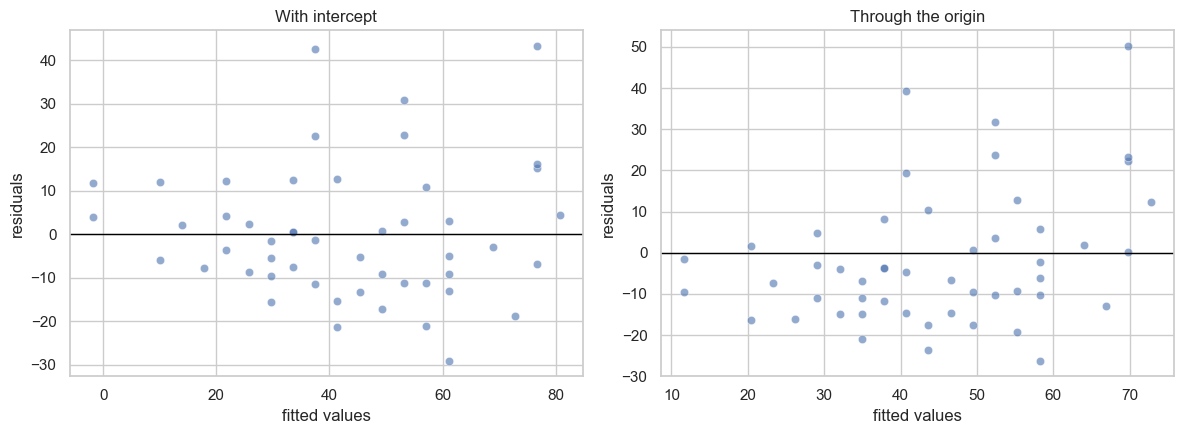

In [21]:
# your solution
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# w/intercept
sns.scatterplot(x=y_hat, y=e_hat, alpha=0.6, ax=axes[0])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlabel('fitted values')
axes[0].set_ylabel('residuals')
axes[0].set_title('With intercept')

# bez interceptu
sns.scatterplot(x=y_hat_origin, y=e_hat_origin, alpha=0.6, ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('fitted values')
axes[1].set_ylabel('residuals')
axes[1].set_title('Through the origin')

plt.tight_layout()
plt.show()

rezidua vypadaji zdraveji u intercept verze modelu. model bez posunu ma chyby vice pod nulou, coz vypovida o nadhodnocovani realnych dat. Kazdopadne jejich rozptyl se zvetsuje.

## Task 10 - An artificial outlier
Add one artificial outlier (for example a large stopping distance at a low speed) and refit both models. How do the coefficients change? Which model is more sensitive?

In [22]:
# your solution
outlier_data = pd.concat([cars, pd.DataFrame({'speed': [5], 'dist': [120]})], ignore_index=True)

X_outlier = outlier_data['speed'].to_numpy()   
Y_outlier = outlier_data['dist'].to_numpy()  
n_outlier = len(X_outlier)

x_mean_outlier = X_outlier.mean()
y_mean_outlier = Y_outlier.mean()

# w/ intercept
beta1_hat_outlier = (np.sum(X_outlier * Y_outlier) - n_outlier * x_mean_outlier * y_mean_outlier) / (np.sum(X_outlier ** 2) - n_outlier * x_mean_outlier ** 2)
beta0_hat_outlier = y_mean_outlier - beta1_hat_outlier * x_mean_outlier

# bez interceptu
beta1_origin_outlier= np.sum(X_outlier * Y_outlier) / np.sum(X_outlier ** 2)

pd.DataFrame({
    'quantity': ['beta0_hat', 'beta1_hat'],
    'with intercept (original)': [beta0_hat, beta1_hat],
    'with intercept (outlier)': [beta0_hat_outlier, beta1_hat_outlier],
    'through origin (original)': [0.0, beta1_origin],
    'through origin (outlier)': [0.0, beta1_origin_outlier],
})

,quantity,with intercept (original),with intercept (outlier),through origin (original),through origin (outlier)
0,beta0_hat,-17.579095,-2.889197,0.000000,0.000000
1,beta1_hat,3.932409,3.117870,2.909132,2.948917


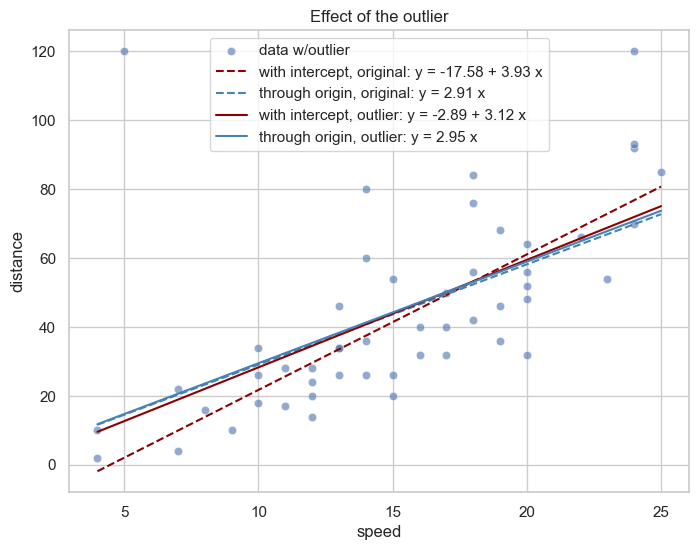

In [23]:
x_line = np.linspace(outlier_data['speed'].min(), outlier_data['speed'].max(), 100)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=outlier_data['speed'], y=outlier_data['dist'], alpha=0.6, label='data w/outlier')
#plt.scatter([5], [120], color='black', marker='X', s=100, zorder=5, label='outlier')

# original data
plt.plot(x_line, beta0_hat + beta1_hat * x_line, color='darkred', linestyle='--',
          label=f'with intercept, original: y = {beta0_hat:.2f} + {beta1_hat:.2f} x')
plt.plot(x_line, beta1_origin * x_line, color='steelblue', linestyle='--',
          label=f'through origin, original: y = {beta1_origin:.2f} x')

# data w/outlier
plt.plot(x_line, beta0_hat_outlier + beta1_hat_outlier * x_line,
          color='darkred', label=f'with intercept, outlier: y = {beta0_hat_outlier:.2f} + {beta1_hat_outlier:.2f} x')
plt.plot(x_line, beta1_origin_outlier * x_line,
          color='steelblue', label=f'through origin, outlier: y = {beta1_origin_outlier:.2f} x')

plt.xlabel('speed')
plt.ylabel('distance')
plt.title('Effect of the outlier')
plt.legend()
plt.show()

outlier ovlivni model a zmenší sklon -> nyní model bez interceptu a s interceptem predikuji prakticky stejně

citlivejsi je model s interceptem (nema zafixovany bod v nule)

## Task 11 - Is a straight line adequate?
Reflect on whether a straight-line model in `speed` is an adequate description. Physics suggests that braking distance grows with the square of speed. Suggest at least two possible next steps (a transformation of a variable, an additional term, ...) and try one of them. Transformations and checking model adequacy are the subject of later lectures; a short reflection and one experiment are enough here.

pokud breaking distance ~ rychlost^2, pak by mozna pomohla transformace sqrt(distance) ~ rychlost.

Popripade pridat kvadraticky clen, který by zaridil zakriveni

In [24]:
# your solution
cars_t = cars.copy()
cars_t['dist'] = np.sqrt(cars_t['dist'])

cars_t.head()

,speed,dist
0,4,1.414214
1,4,3.162278
2,7,2.000000
3,7,4.690416
4,8,4.000000


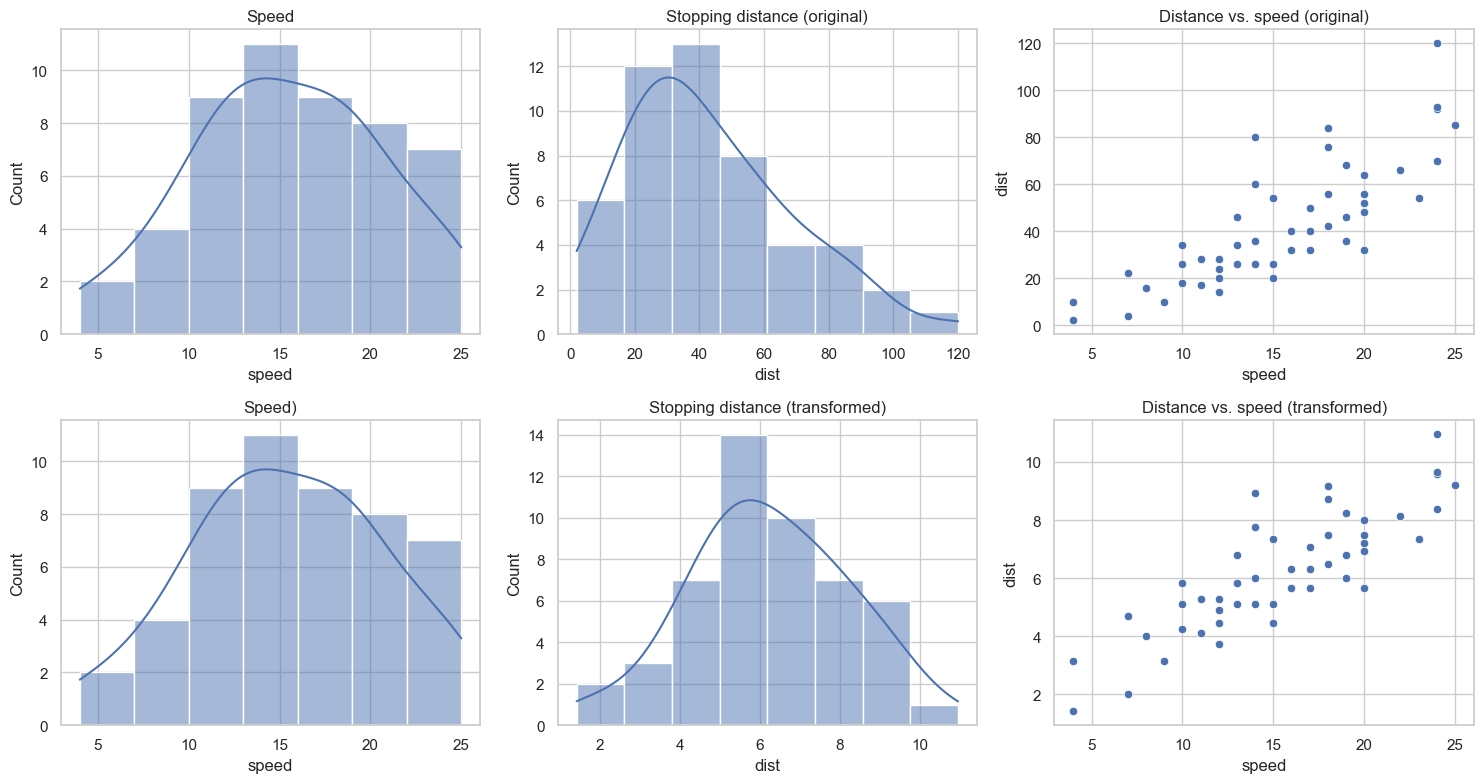

In [25]:
# your solution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# orig
sns.histplot(cars['speed'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Speed')

sns.histplot(cars['dist'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Stopping distance (original)')

sns.scatterplot(x='speed', y='dist', data=cars, ax=axes[0, 2])
axes[0, 2].set_title('Distance vs. speed (original)')

# transformed
sns.histplot(cars_t['speed'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Speed)')

sns.histplot(cars_t['dist'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Stopping distance (transformed)')

sns.scatterplot(x='speed', y='dist', data=cars_t, ax=axes[1, 2])
axes[1, 2].set_title('Distance vs. speed (transformed)')

plt.tight_layout()
plt.show()

In [26]:
X_t = cars_t['speed'].to_numpy()   
Y_t = cars_t['dist'].to_numpy()  
n_t = len(X_t)

x_mean_t = X_t.mean()
y_mean_t = Y_t.mean()

# w/ intercept
beta1_hat_t = (np.sum(X_t * Y_t) - n_t * x_mean_t * y_mean_t) / (np.sum(X_t ** 2) - n_t * x_mean_t ** 2)
beta0_hat_t = y_mean_t - beta1_hat_t * x_mean_t

# bez interceptu
beta1_origin_t= np.sum(X_t * Y_t) / np.sum(X_t ** 2)

pd.DataFrame({
    'quantity': ['beta0_hat', 'beta1_hat'],
    'with intercept (original)': [beta0_hat, beta1_hat],
    'with intercept (transformed)': [beta0_hat_t, beta1_hat_t],
    'through origin (original)': [np.nan, beta1_origin],
    'through origin (transformed)': [np.nan, beta1_origin_t],
})

,quantity,with intercept (original),with intercept (transformed),through origin (original),through origin (transformed)
0,beta0_hat,-17.579095,1.277050,NaN,NaN
1,beta1_hat,3.932409,0.322413,2.909132,0.396749


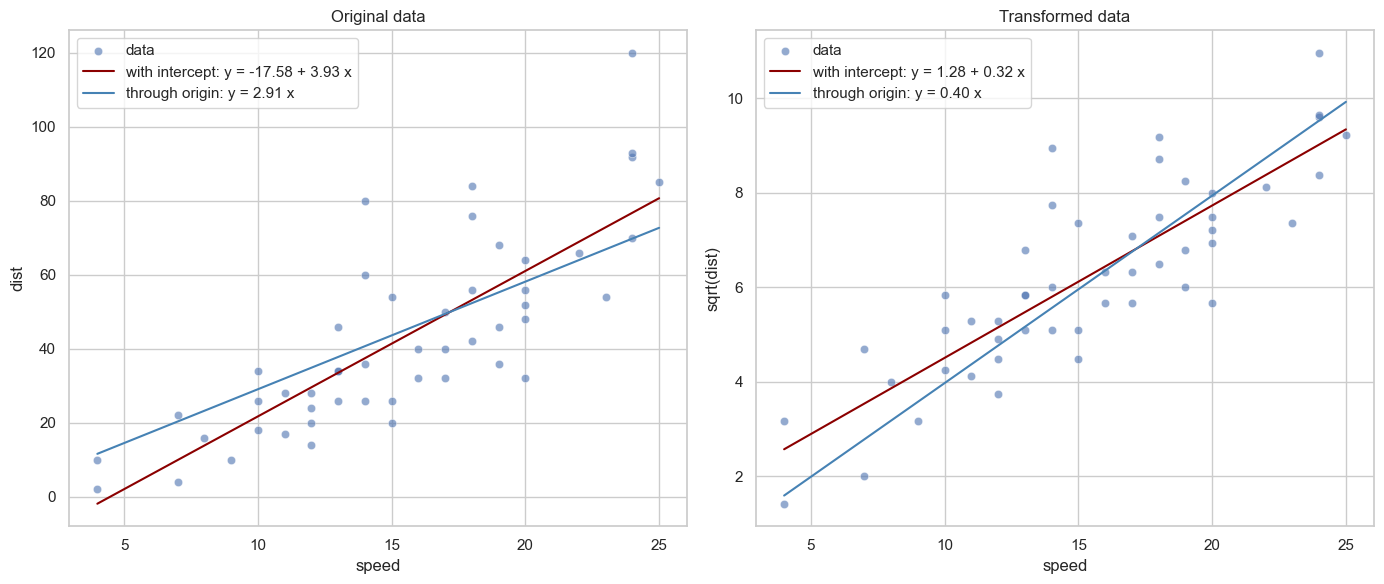

In [27]:
# your solution
x_line = np.linspace(X.min(), X.max(), 100)
x_line_t = np.linspace(cars_t['speed'].min(), cars_t['speed'].max(), 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# original data
sns.scatterplot(x=X, y=Y, alpha=0.6, ax=axes[0], label='data')
axes[0].plot(x_line, beta0_hat + beta1_hat * x_line, color='darkred',
             label=f'with intercept: y = {beta0_hat:.2f} + {beta1_hat:.2f} x')
axes[0].plot(x_line, beta1_origin * x_line, color='steelblue',
             label=f'through origin: y = {beta1_origin:.2f} x')
axes[0].set_xlabel('speed')
axes[0].set_ylabel('dist')
axes[0].set_title('Original data')
axes[0].legend()

# transformed data
sns.scatterplot(x=cars_t['speed'], y=cars_t['dist'], alpha=0.6, ax=axes[1], label='data')
axes[1].plot(x_line_t, beta0_hat_t + beta1_hat_t * x_line_t, color='darkred',
             label=f'with intercept: y = {beta0_hat_t:.2f} + {beta1_hat_t:.2f} x')
axes[1].plot(x_line_t, beta1_origin_t * x_line_t, color='steelblue',
             label=f'through origin: y = {beta1_origin_t:.2f} x')
axes[1].set_xlabel('speed')
axes[1].set_ylabel('sqrt(dist)')
axes[1].set_title('Transformed data')
axes[1].legend()

plt.tight_layout()
plt.show()

In [28]:
# predikce
x_new = np.array([20, 30])

# w/intercept
pred_intercept = beta0_hat + beta1_hat * x_new

# bez interceptu
pred_origin = beta1_origin * x_new

# transformed w/intercept
pred_intercept_t = (beta0_hat_t + beta1_hat_t * x_new) ** 2

# transformed bez interceptu
pred_origin_t = (beta1_origin_t * x_new) ** 2

pd.DataFrame({
    'speed': x_new,
    'with intercept': pred_intercept,
    'through the origin': pred_origin,
    'with intercept transformed': pred_intercept_t,
    'through the origin transformed': pred_origin_t,
})

,speed,with intercept,through the origin,with intercept transformed,through the origin transformed
0,20,61.069080,58.182643,59.680266,62.964041
1,30,100.393168,87.273964,119.889917,141.669091


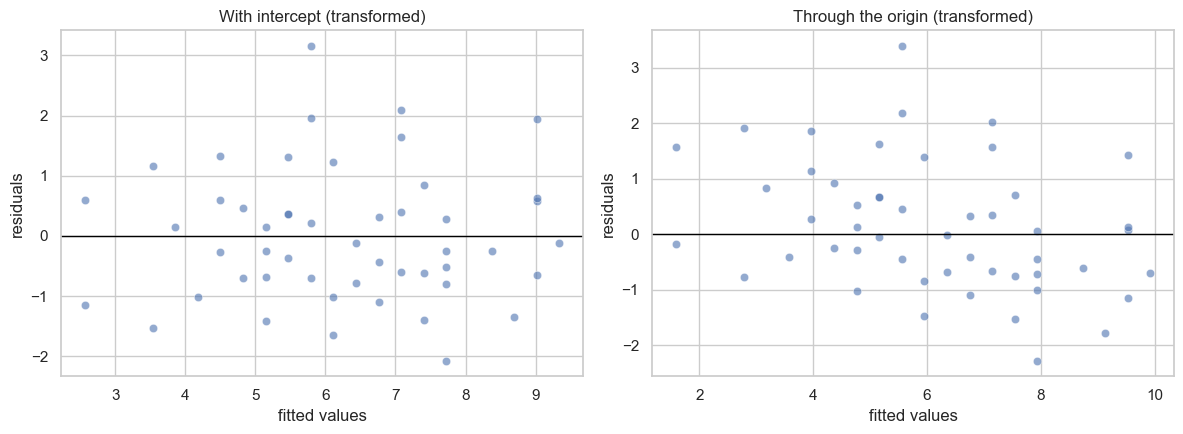

In [29]:
# your solution
y_hat_t = beta0_hat_t + beta1_hat_t * X_t
e_hat_t = Y_t - y_hat_t

y_hat_origin_t = beta1_origin_t * X_t
e_hat_origin_t = Y_t - y_hat_origin_t

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# w/intercept
sns.scatterplot(x=y_hat_t, y=e_hat_t, alpha=0.6, ax=axes[0])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlabel('fitted values')
axes[0].set_ylabel('residuals')
axes[0].set_title('With intercept (transformed)')

# bez interceptu
sns.scatterplot(x=y_hat_origin_t, y=e_hat_origin_t, alpha=0.6, ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('fitted values')
axes[1].set_ylabel('residuals')
axes[1].set_title('Through the origin (transformed)')

plt.tight_layout()
plt.show()